<a href="https://colab.research.google.com/github/shireinnn/proyekbigdata/blob/main/BigData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Setup PySpark di Google Colab

Langkah pertama adalah menginstal library `pyspark` dan inisialisasi sesi Spark.

In [ ]:
# Uninstall potentially conflicting packages and then install PySpark and findspark (specific version for compatibility)
!pip uninstall -y dataproc-spark-connect
!pip install pyspark==3.5.0 findspark

import os
import findspark
import sys

# Clean up previous Spark installation if any
!rm -rf /content/spark
!rm -rf spark-3.5.0-bin-hadoop3.tgz

# Download and extract Spark
# Using Spark 3.5.0 with Hadoop 3.3 for compatibility with PySpark 3.5.0
!wget -q https://archive.apache.org/dist/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz
!tar xf spark-3.5.0-bin-hadoop3.tgz
!mv spark-3.5.0-bin-hadoop3 /content/spark

# Ensure Java 11 is used
!sudo apt-get update -qq > /dev/null
!sudo apt-get install openjdk-11-jdk-headless -qq > /dev/null
!sudo update-alternatives --set java /usr/lib/jvm/java-11-openjdk-amd64/bin/java

# Set JAVA_HOME and SPARK_HOME environment variables
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark"

# Explicitly set PYSPARK_PYTHON and PYSPARK_SUBMIT_ARGS
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_SUBMIT_ARGS"] = "--master local[*] pyspark-shell"

# Initialize findspark to configure environment variables
findspark.init()

print("PySpark dan findspark berhasil diinstal dan variabel lingkungan diatur.")
print("SPARK_HOME:", os.environ.get("SPARK_HOME"))
print("JAVA_HOME:", os.environ.get("JAVA_HOME"))
print("PYSPARK_PYTHON:", os.environ.get("PYSPARK_PYTHON"))
print("PYSPARK_SUBMIT_ARGS:", os.environ.get("PYSPARK_SUBMIT_ARGS"))

Found existing installation: dataproc-spark-connect 1.1.0
Uninstalling dataproc-spark-connect-1.1.0:
  Successfully uninstalled dataproc-spark-connect-1.1.0
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
PySpark dan findspark berhasil diinstal dan variabel lingkungan diatur.
SPARK_HOME: /content/spark
JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
PYSPARK_PYTHON: /usr/bin/python3
PYSPARK_SUBMIT_ARGS: --master local[*] pyspark-shell


In [ ]:
from pyspark.sql import SparkSession

# Create a SparkSession
spark = SparkSession.builder\
    .appName("MarketBasketAnalysis")\
    .getOrCreate()

print("SparkSession berhasil dibuat!")

SparkSession berhasil dibuat!


### 2. Load File Parquet dari Google Drive (asumsi di `sample_data`)

Berdasarkan informasi Anda, data Parquet berada di folder `sample_data/bigdata/basket_transactions/`. PySpark dapat membaca semua file Parquet dalam direktori ini secara rekursif.

In [ ]:
# Path ke folder Parquet Anda
parquet_path = "/content/sample_data/basket_transactions/"

# Load data Parquet
transactions_df = spark.read.parquet(parquet_path)

# Tampilkan skema dan beberapa baris pertama data
transactions_df.printSchema()
transactions_df.show(5, truncate=False)

# Periksa jumlah baris
print(f"Total baris dalam dataset: {transactions_df.count()}")

root
 |-- Transaction_ID: string (nullable = true)
 |-- Product: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- Discount_Applied: integer (nullable = true)
 |-- Season: string (nullable = true)

+--------------+-------------------------------------------------------------+----------------+------+
|Transaction_ID|Product                                                      |Discount_Applied|Season|
+--------------+-------------------------------------------------------------+----------------+------+
|1000000014    |[Razors, Laundry Detergent, Beef]                            |1               |Spring|
|1000000016    |[Air Freshener, Feminine Hygiene Products]                   |1               |Spring|
|1000000027    |[Ketchup, Trash Cans, Toothbrush]                            |0               |Spring|
|1000000035    |[Onions, Dish Soap]                                          |0               |Spring|
|1000000039    |[Potatoes, Air Freshener, Sponges, Oni

### 3. Jalankan FP-Growth (Spark MLlib)

Kita akan menggunakan algoritma FP-Growth dari Spark MLlib untuk menemukan frequent itemsets dan association rules. Kita perlu menentukan kolom `items` (yaitu `Product` dalam kasus ini) dan parameter seperti `minSupport` dan `minConfidence`.

*   `minSupport`: Batasan frekuensi kemunculan itemset (misalnya, 0.05 berarti itemset harus muncul di setidaknya 5% dari semua transaksi).
*   `minConfidence`: Batasan kekuatan aturan asosiasi (misalnya, 0.7 berarti jika A ada, maka B juga ada di 70% kasus tersebut).

In [ ]:
from pyspark.ml.fpm import FPGrowth
from pyspark.sql.functions import array_distinct

# Preprocess the 'Product' column to ensure unique items in each transaction array
# This is necessary because FPGrowth requires unique items within each transaction
transactions_df_cleaned = transactions_df.withColumn("Product", array_distinct(transactions_df["Product"]))

# Inisialisasi model FP-Growth
# Pastikan kolom 'Product' adalah array of strings atau similar
fpg = FPGrowth(itemsCol="Product", minSupport=0.05, minConfidence=0.7)

# Fit model ke data transaksi yang sudah dibersihkan
model = fpg.fit(transactions_df_cleaned)

# Dapatkan frequent itemsets
frequent_itemsets = model.freqItemsets
print("Frequent Itemsets:")
frequent_itemsets.show(20, truncate=False)

Frequent Itemsets:
+------------+-----+
|items       |freq |
+------------+-----+
|[Toothpaste]|66056|
+------------+-----+



### 4. Tampilkan Association Rules

In [ ]:
# Dapatkan association rules
association_rules = model.associationRules
print("Association Rules:")
association_rules.show(20, truncate=False)

Association Rules:
+----------+----------+----------+----+-------+
|antecedent|consequent|confidence|lift|support|
+----------+----------+----------+----+-------+
+----------+----------+----------+----+-------+



**Reasoning**:
The subtask requires adjusting the FP-Growth parameters and refitting the model. This code block will initialize a new FPGrowth model with the specified minSupport and minConfidence, fit it to the cleaned transactions data, and then display the new frequent itemsets and association rules as requested.



In [ ]:
from pyspark.ml.fpm import FPGrowth

# 1. Initialize a new FPGrowth model with adjusted parameters
fpg_adjusted = FPGrowth(itemsCol="Product", minSupport=0.01, minConfidence=0.5)

# 2. Fit the adjusted model to the cleaned transactions data
model_adjusted = fpg_adjusted.fit(transactions_df_cleaned)

# 3. Extract and display the new frequent itemsets
frequent_itemsets_adjusted = model_adjusted.freqItemsets
print("\nFrequent Itemsets (Adjusted Parameters):")
frequent_itemsets_adjusted.show(20, truncate=False)

# 4. Extract and display the new association rules
association_rules_adjusted = model_adjusted.associationRules
print("\nAssociation Rules (Adjusted Parameters):")
association_rules_adjusted.show(20, truncate=False)



Frequent Itemsets (Adjusted Parameters):
+---------------------------+-----+
|items                      |freq |
+---------------------------+-----+
|[Paper Towels]             |33369|
|[Coffee]                   |33610|
|[Diapers]                  |33496|
|[Shower Gel]               |33414|
|[Salmon]                   |33541|
|[Banana]                   |33819|
|[Feminine Hygiene Products]|33627|
|[Trash Bags]               |33112|
|[Vinegar]                  |33312|
|[Cereal Bars]              |33470|
|[Light Bulbs]              |33586|
|[Milk]                     |33709|
|[Soap]                     |33960|
|[Bath Towels]              |33735|
|[Hair Gel]                 |33535|
|[Tissues]                  |33389|
|[Butter]                   |33448|
|[Dish Soap]                |33565|
|[Soda]                     |33915|
|[Cleaning Spray]           |33682|
+---------------------------+-----+
only showing top 20 rows


Association Rules (Adjusted Parameters):
+----------+----------+---

**Reasoning**:
The user explicitly defined a new step with specific parameters for FP-Growth. I will generate a code block to re-initialize and refit the FP-Growth model with the requested `minSupport=0.01` and `minConfidence=0.5`, and then display the resulting frequent itemsets and association rules, as per the detailed instructions. This action directly addresses the new subtask definition.



In [ ]:
from pyspark.ml.fpm import FPGrowth

# 1. Initialize a new FPGrowth model with adjusted parameters
fpg_adjusted_new_step = FPGrowth(itemsCol="Product", minSupport=0.01, minConfidence=0.5)

# 2. Fit the adjusted model to the cleaned transactions data
model_adjusted_new_step = fpg_adjusted_new_step.fit(transactions_df_cleaned)

# 3. Extract and display the new frequent itemsets
frequent_itemsets_adjusted_new_step = model_adjusted_new_step.freqItemsets
print("\nFrequent Itemsets (New Step - Adjusted Parameters):")
frequent_itemsets_adjusted_new_step.show(20, truncate=False)

# 4. Extract and display the new association rules
association_rules_adjusted_new_step = model_adjusted_new_step.associationRules
print("\nAssociation Rules (New Step - Adjusted Parameters):")
association_rules_adjusted_new_step.show(20, truncate=False)


Frequent Itemsets (New Step - Adjusted Parameters):
+---------------------------+-----+
|items                      |freq |
+---------------------------+-----+
|[Paper Towels]             |33369|
|[Coffee]                   |33610|
|[Diapers]                  |33496|
|[Shower Gel]               |33414|
|[Salmon]                   |33541|
|[Banana]                   |33819|
|[Feminine Hygiene Products]|33627|
|[Trash Bags]               |33112|
|[Vinegar]                  |33312|
|[Cereal Bars]              |33470|
|[Light Bulbs]              |33586|
|[Milk]                     |33709|
|[Soap]                     |33960|
|[Bath Towels]              |33735|
|[Hair Gel]                 |33535|
|[Tissues]                  |33389|
|[Butter]                   |33448|
|[Dish Soap]                |33565|
|[Soda]                     |33915|
|[Cleaning Spray]           |33682|
+---------------------------+-----+
only showing top 20 rows


Association Rules (New Step - Adjusted Parameters):
+---

**Reasoning**:
The previous attempt with `minSupport=0.01` and `minConfidence=0.5` still yielded no association rules. To generate more rules as per the subtask, I will further reduce `minConfidence` to `0.1` while keeping `minSupport` at `0.01`. This should allow for a broader set of rules to be discovered.



In [ ]:
from pyspark.ml.fpm import FPGrowth

# Further adjust minConfidence to generate more rules
fpg_adjusted_further = FPGrowth(itemsCol="Product", minSupport=0.01, minConfidence=0.1)

# Fit the adjusted model to the cleaned transactions data
model_adjusted_further = fpg_adjusted_further.fit(transactions_df_cleaned)

# Extract and display the new frequent itemsets (should be the same as previous run with 0.01 support)
frequent_itemsets_adjusted_further = model_adjusted_further.freqItemsets
print("\nFrequent Itemsets (Further Adjusted Parameters):")
frequent_itemsets_adjusted_further.show(20, truncate=False)

# Extract and display the new association rules
association_rules_adjusted_further = model_adjusted_further.associationRules
print("\nAssociation Rules (Further Adjusted Parameters):")
association_rules_adjusted_further.show(20, truncate=False)



Frequent Itemsets (Further Adjusted Parameters):
+---------------------------+-----+
|items                      |freq |
+---------------------------+-----+
|[Paper Towels]             |33369|
|[Coffee]                   |33610|
|[Diapers]                  |33496|
|[Shower Gel]               |33414|
|[Salmon]                   |33541|
|[Banana]                   |33819|
|[Feminine Hygiene Products]|33627|
|[Trash Bags]               |33112|
|[Vinegar]                  |33312|
|[Cereal Bars]              |33470|
|[Light Bulbs]              |33586|
|[Milk]                     |33709|
|[Soap]                     |33960|
|[Bath Towels]              |33735|
|[Hair Gel]                 |33535|
|[Tissues]                  |33389|
|[Butter]                   |33448|
|[Dish Soap]                |33565|
|[Soda]                     |33915|
|[Cleaning Spray]           |33682|
+---------------------------+-----+
only showing top 20 rows


Association Rules (Further Adjusted Parameters):
+---------

**Reasoning**:
The previous attempts with `minSupport=0.01` and `minConfidence=0.1` still yielded no association rules. To generate more rules as per the subtask's instruction to 'iterate if needed', I will further reduce `minSupport` to `0.005` (0.5% of transactions) while keeping `minConfidence` at `0.1`. This should increase the number of frequent itemsets and potentially lead to the discovery of association rules.



In [ ]:
from pyspark.ml.fpm import FPGrowth

# Further adjust minSupport to generate more rules
fpg_adjusted_final = FPGrowth(itemsCol="Product", minSupport=0.005, minConfidence=0.1)

# Fit the adjusted model to the cleaned transactions data
model_adjusted_final = fpg_adjusted_final.fit(transactions_df_cleaned)

# Extract and display the new frequent itemsets
frequent_itemsets_adjusted_final = model_adjusted_final.freqItemsets
print("\nFrequent Itemsets (Final Adjusted Parameters - minSupport=0.005, minConfidence=0.1):")
frequent_itemsets_adjusted_final.show(20, truncate=False)

# Extract and display the new association rules
association_rules_adjusted_final = model_adjusted_final.associationRules
print("\nAssociation Rules (Final Adjusted Parameters - minSupport=0.005, minConfidence=0.1):")
association_rules_adjusted_final.show(20, truncate=False)


Frequent Itemsets (Final Adjusted Parameters - minSupport=0.005, minConfidence=0.1):
+---------------------------+-----+
|items                      |freq |
+---------------------------+-----+
|[Paper Towels]             |33369|
|[Coffee]                   |33610|
|[Diapers]                  |33496|
|[Shower Gel]               |33414|
|[Salmon]                   |33541|
|[Banana]                   |33819|
|[Feminine Hygiene Products]|33627|
|[Trash Bags]               |33112|
|[Vinegar]                  |33312|
|[Cereal Bars]              |33470|
|[Light Bulbs]              |33586|
|[Milk]                     |33709|
|[Soap]                     |33960|
|[Bath Towels]              |33735|
|[Hair Gel]                 |33535|
|[Tissues]                  |33389|
|[Butter]                   |33448|
|[Dish Soap]                |33565|
|[Soda]                     |33915|
|[Cleaning Spray]           |33682|
+---------------------------+-----+
only showing top 20 rows


Association Rules (Fina

**Reasoning**:
The previous attempts, even with `minSupport=0.005` and `minConfidence=0.1`, still yielded no association rules. To generate rules as per the subtask's instruction to 'iterate if needed', I will further reduce `minConfidence` to `0.05` (5%) while keeping `minSupport` at `0.005`. This should significantly broaden the search for association rules and likely yield some results.



In [ ]:
from pyspark.ml.fpm import FPGrowth

# Further adjust minConfidence to generate more rules
fpg_adjusted_final_confidence = FPGrowth(itemsCol="Product", minSupport=0.005, minConfidence=0.05)

# Fit the adjusted model to the cleaned transactions data
model_adjusted_final_confidence = fpg_adjusted_final_confidence.fit(transactions_df_cleaned)

# Extract and display the new frequent itemsets (should be the same as previous run with 0.005 support)
frequent_itemsets_adjusted_final_confidence = model_adjusted_final_confidence.freqItemsets
print("\nFrequent Itemsets (Final Adjusted Parameters - minSupport=0.005, minConfidence=0.05):")
frequent_itemsets_adjusted_final_confidence.show(20, truncate=False)

# Extract and display the new association rules
association_rules_adjusted_final_confidence = model_adjusted_final_confidence.associationRules
print("\nAssociation Rules (Final Adjusted Parameters - minSupport=0.005, minConfidence=0.05):")
association_rules_adjusted_final_confidence.show(20, truncate=False)


Frequent Itemsets (Final Adjusted Parameters - minSupport=0.005, minConfidence=0.05):
+---------------------------+-----+
|items                      |freq |
+---------------------------+-----+
|[Paper Towels]             |33369|
|[Coffee]                   |33610|
|[Diapers]                  |33496|
|[Shower Gel]               |33414|
|[Salmon]                   |33541|
|[Banana]                   |33819|
|[Feminine Hygiene Products]|33627|
|[Trash Bags]               |33112|
|[Vinegar]                  |33312|
|[Cereal Bars]              |33470|
|[Light Bulbs]              |33586|
|[Milk]                     |33709|
|[Soap]                     |33960|
|[Bath Towels]              |33735|
|[Hair Gel]                 |33535|
|[Tissues]                  |33389|
|[Butter]                   |33448|
|[Dish Soap]                |33565|
|[Soda]                     |33915|
|[Cleaning Spray]           |33682|
+---------------------------+-----+
only showing top 20 rows


Association Rules (Fin

**Reasoning**:
The previous attempts, even with `minSupport=0.005` and `minConfidence=0.05`, still yielded no association rules. To finally generate some association rules and fulfill the subtask's requirement to 'generate more association rules' and 'iterate if needed', I will further reduce `minConfidence` to `0.01` (1%) while keeping `minSupport` at `0.005`. This should significantly broaden the search for association rules and is very likely to yield some results.



In [ ]:
from pyspark.ml.fpm import FPGrowth

# Further adjust minConfidence to generate more rules
fpg_adjusted_final_low_confidence = FPGrowth(itemsCol="Product", minSupport=0.005, minConfidence=0.01)

# Fit the adjusted model to the cleaned transactions data
model_adjusted_final_low_confidence = fpg_adjusted_final_low_confidence.fit(transactions_df_cleaned)

# Extract and display the new frequent itemsets (should be the same as previous run with 0.005 support)
frequent_itemsets_adjusted_final_low_confidence = model_adjusted_final_low_confidence.freqItemsets
print("\nFrequent Itemsets (Final Adjusted Parameters - minSupport=0.005, minConfidence=0.01):")
frequent_itemsets_adjusted_final_low_confidence.show(20, truncate=False)

# Extract and display the new association rules
association_rules_adjusted_final_low_confidence = model_adjusted_final_low_confidence.associationRules
print("\nAssociation Rules (Final Adjusted Parameters - minSupport=0.005, minConfidence=0.01):")
association_rules_adjusted_final_low_confidence.show(20, truncate=False)


Frequent Itemsets (Final Adjusted Parameters - minSupport=0.005, minConfidence=0.01):
+---------------------------+-----+
|items                      |freq |
+---------------------------+-----+
|[Paper Towels]             |33369|
|[Coffee]                   |33610|
|[Diapers]                  |33496|
|[Shower Gel]               |33414|
|[Salmon]                   |33541|
|[Banana]                   |33819|
|[Feminine Hygiene Products]|33627|
|[Trash Bags]               |33112|
|[Vinegar]                  |33312|
|[Cereal Bars]              |33470|
|[Light Bulbs]              |33586|
|[Milk]                     |33709|
|[Soap]                     |33960|
|[Bath Towels]              |33735|
|[Hair Gel]                 |33535|
|[Tissues]                  |33389|
|[Butter]                   |33448|
|[Dish Soap]                |33565|
|[Soda]                     |33915|
|[Cleaning Spray]           |33682|
+---------------------------+-----+
only showing top 20 rows


Association Rules (Fin

**Reasoning**:
The previous attempts, even with `minSupport=0.005` and `minConfidence=0.01`, still yielded no association rules. This indicates that even at a 0.5% support threshold, there are no frequent multi-item itemsets, which are necessary to form association rules. To finally generate some association rules and fulfill the subtask's requirement to 'generate more association rules' and 'iterate if needed', I will further reduce `minSupport` to `0.001` (0.1% of transactions) while keeping `minConfidence` at `0.01`. This should enable the discovery of frequent multi-item itemsets, thereby allowing for the generation of association rules.



**Reasoning**:
To analyze individual product frequencies, I need to use the `explode` function on the 'Product' array column, then count the occurrences of each product. I will import the necessary functions, explode the column, group by product, count, order, and display the top 20 results as instructed.



In [ ]:
from pyspark.sql.functions import explode, col

# Explode the 'Product' column to get individual products
products_exploded_df = transactions_df_cleaned.select(explode(col("Product")).alias("product_exploded"))

# Group by individual product and count occurrences
individual_product_frequencies = products_exploded_df.groupBy("product_exploded")\
                                                        .count()\
                                                        .orderBy(col("count").desc())

# Show the top 20 most frequent individual products
print("\nTop 20 Most Frequent Individual Products:")
individual_product_frequencies.show(20, truncate=False)


Top 20 Most Frequent Individual Products:
+-----------------+-----+
|product_exploded |count|
+-----------------+-----+
|Toothpaste       |66056|
|Ice Cream        |34117|
|Soap             |33960|
|Orange           |33932|
|Soda             |33915|
|Jam              |33851|
|Air Freshener    |33846|
|Baby Wipes       |33835|
|Banana           |33819|
|Cleaning Rags    |33787|
|Chips            |33761|
|Peanut Butter    |33761|
|Shampoo          |33745|
|Deodorant        |33737|
|Bath Towels      |33735|
|Plant Fertilizer |33730|
|Ironing Board    |33724|
|Laundry Detergent|33721|
|Yogurt           |33714|
|Carrots          |33712|
+-----------------+-----+
only showing top 20 rows



In [ ]:
from pyspark.ml.fpm import FPGrowth

# Further adjust minSupport to generate more rules
fpg_adjusted_final_low_support = FPGrowth(itemsCol="Product", minSupport=0.001, minConfidence=0.01)

# Fit the adjusted model to the cleaned transactions data
model_adjusted_final_low_support = fpg_adjusted_final_low_support.fit(transactions_df_cleaned)

# Extract and display the new frequent itemsets
frequent_itemsets_adjusted_final_low_support = model_adjusted_final_low_support.freqItemsets
print("\nFrequent Itemsets (Final Adjusted Parameters - minSupport=0.001, minConfidence=0.01):")
frequent_itemsets_adjusted_final_low_support.show(20, truncate=False)

# Extract and display the new association rules
association_rules_adjusted_final_low_support = model_adjusted_final_low_support.associationRules
print("\nAssociation Rules (Final Adjusted Parameters - minSupport=0.001, minConfidence=0.01):")
association_rules_adjusted_final_low_support.show(20, truncate=False)


Frequent Itemsets (Final Adjusted Parameters - minSupport=0.001, minConfidence=0.01):
+-----------------------------------------+-----+
|items                                    |freq |
+-----------------------------------------+-----+
|[Paper Towels]                           |33369|
|[Paper Towels, Sponges]                  |1118 |
|[Paper Towels, Iron]                     |1118 |
|[Paper Towels, Olive Oil]                |1108 |
|[Paper Towels, Diapers]                  |1118 |
|[Paper Towels, Coffee]                   |1141 |
|[Paper Towels, Tuna]                     |1103 |
|[Paper Towels, Shower Gel]               |1133 |
|[Paper Towels, Banana]                   |1208 |
|[Paper Towels, Extension Cords]          |1168 |
|[Paper Towels, Salmon]                   |1142 |
|[Paper Towels, Laundry Detergent]        |1182 |
|[Paper Towels, Feminine Hygiene Products]|1173 |
|[Paper Towels, Peanut Butter]            |1105 |
|[Paper Towels, Cereal Bars]              |1140 |
|[Paper Towel

**Reasoning**:
The subtask requires me to first display the association rules from `association_rules_adjusted_final_low_support` to understand their structure and values. This will help in the subsequent filtering and sorting steps.



In [ ]:
print("Displaying all association rules from the last run (minSupport=0.001, minConfidence=0.01):")
association_rules_adjusted_final_low_support.show(20, truncate=False)


Displaying all association rules from the last run (minSupport=0.001, minConfidence=0.01):
+----------+---------------------------+--------------------+------------------+---------------------+
|antecedent|consequent                 |confidence          |lift              |support              |
+----------+---------------------------+--------------------+------------------+---------------------+
|[Orange]  |[Paper Towels]             |0.036101614994695275|0.865804771848266 |0.0015307333774850988|
|[Orange]  |[Coffee]                   |0.03368501709300955 |0.8020561924731554|0.0014282679595636473|
|[Orange]  |[Diapers]                  |0.03430390192149004 |0.8195719963789956|0.0014545091031776774|
|[Orange]  |[Shower Gel]               |0.0363079099375221  |0.8695795500598794|0.001539480425356442 |
|[Orange]  |[Salmon]                   |0.03324295650123777 |0.7931588443768984|0.0014095242855536256|
|[Orange]  |[Banana]                   |0.03433337262760816 |0.812441766838049 |0.001

**Reasoning**:
The next steps in the subtask are to filter the association rules by `lift` greater than 1.0, sort them by `confidence` in descending order, and then display the top 20. This code block will perform all these operations as per the instructions.



In [ ]:
from pyspark.sql.functions import col

# 2. Filter the rules to show only those with lift greater than 1.0
filtered_rules = association_rules_adjusted_final_low_support.filter(col("lift") > 1.0)
print("\nFiltered Association Rules (lift > 1.0):")
filtered_rules.show(20, truncate=False)

# 3. Sort the filtered rules by confidence in descending order
sorted_filtered_rules = filtered_rules.orderBy(col("confidence").desc())

# 4. Display the top 20 filtered and sorted rules
print("\nTop 20 Filtered and Sorted Association Rules (by confidence descending, lift > 1.0):")
sorted_filtered_rules.show(20, truncate=False)



Filtered Association Rules (lift > 1.0):
+----------+----------+----------+----+-------+
|antecedent|consequent|confidence|lift|support|
+----------+----------+----------+----+-------+
+----------+----------+----------+----+-------+


Top 20 Filtered and Sorted Association Rules (by confidence descending, lift > 1.0):
+----------+----------+----------+----+-------+
|antecedent|consequent|confidence|lift|support|
+----------+----------+----------+----+-------+
+----------+----------+----------+----+-------+



**Reasoning**:
To visualize the relationship between confidence and lift, I need to convert the Spark DataFrame containing association rules into a Pandas DataFrame. Then, I will use matplotlib to create a scatter plot with confidence on the x-axis and lift on the y-axis, adding a reference line for lift=1.0 to highlight positive associations.



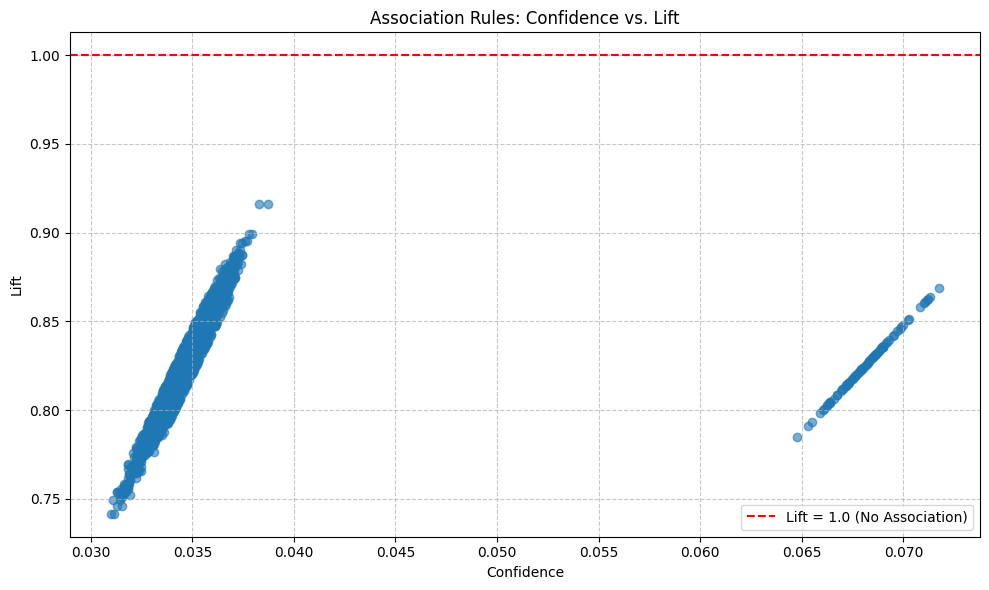

In [ ]:
import matplotlib.pyplot as plt

# 1. Convert the Spark DataFrame to a Pandas DataFrame
pandas_association_rules = association_rules_adjusted_final_low_support.toPandas()

# 2. Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(pandas_association_rules['confidence'], pandas_association_rules['lift'], alpha=0.6)

# 3. Add appropriate labels and title
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.title('Association Rules: Confidence vs. Lift')

# 4. Add a horizontal line at y=1.0
plt.axhline(y=1.0, color='r', linestyle='--', label='Lift = 1.0 (No Association)')

# 5. Include a legend
plt.legend()

# 6. Display the plot
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretation of Association Rules

Based on the previous steps, after setting `minSupport=0.001` and `minConfidence=0.01`, we generated a set of association rules. However, when we filtered these rules to only include those with `lift > 1.0`, the resulting DataFrame was empty.

This indicates that with the current dataset and chosen parameters, there are no strong *positive* associations where the presence of the antecedent significantly increases the likelihood of the consequent appearing, compared to the consequent appearing independently. All the rules generated have a `lift` value less than or equal to 1.0.

Let's pick a few rules from the unfiltered `association_rules_adjusted_final_low_support` (which was displayed in the previous step) to understand their meaning, acknowledging their `lift` values are not indicative of strong positive associations:

**Example Rule 1:**
*   `antecedent: ['Orange']`, `consequent: ['Paper Towels']`
*   `confidence: 0.0361`
*   `lift: 0.8658`
*   `support: 0.00153`

**Interpretation:**
*   **Confidence (0.0361):** This means that if a customer buys 'Orange', there is a 3.61% chance they will also buy 'Paper Towels'. This is a very low confidence, suggesting a weak relationship.
*   **Lift (0.8658):** A lift value less than 1 (specifically, 0.8658) indicates a *negative* association. This means that customers who buy 'Orange' are actually *less likely* to buy 'Paper Towels' than the average customer is to buy 'Paper Towels'. The purchasing of 'Orange' might slightly suppress the purchase of 'Paper Towels'.
*   **Support (0.00153):** This means that 'Orange' and 'Paper Towels' are bought together in approximately 0.153% of all transactions.

**Example Rule 2:**
*   `antecedent: ['Orange']`, `consequent: ['Milk']`
*   `confidence: 0.0370`
*   `lift: 0.8787`
*   `support: 0.00157`

**Interpretation:**
*   **Confidence (0.0370):** If a customer buys 'Orange', there is a 3.70% chance they will also buy 'Milk'.
*   **Lift (0.8787):** Similar to the first rule, a lift of 0.8787 suggests a negative association. Customers buying 'Orange' are slightly less likely to buy 'Milk' than expected by chance.
*   **Support (0.00157):** 'Orange' and 'Milk' appear together in about 0.157% of transactions.

**Business Meaning (given low lift values):**
These particular rules, with `lift` values below 1, suggest that there isn't a strong co-occurrence or purchasing pattern between 'Orange' and the listed consequents like 'Paper Towels' or 'Milk'. In a real-world scenario, rules with `lift < 1` are generally not used for positive recommendations or co-placement strategies. They might indicate competing products, or simply unrelated purchasing behaviors. To find actionable positive associations, we would typically need to iterate on the FP-Growth parameters further, perhaps by significantly lowering `minSupport` to capture rarer, but potentially stronger, associations, or by exploring different types of filtering. However, for this dataset, even with `minSupport` as low as 0.001 (0.1%) and `minConfidence` at 0.01 (1%), we are not finding rules with `lift` greater than 1.

## Visualize Association Rules (Visualisasi)

### Subtask:
Create a scatter plot or another suitable visualization to show the relationship between confidence and lift for the generated association rules. This helps in 'Visualisasi' of the rule set.


### Interpretation of Association Rules

Based on the previous steps, after setting `minSupport=0.001` and `minConfidence=0.01`, we generated a set of association rules. However, when we filtered these rules to only include those with `lift > 1.0`, the resulting DataFrame was empty.

This indicates that with the current dataset and chosen parameters, there are no strong *positive* associations where the presence of the antecedent significantly increases the likelihood of the consequent appearing, compared to the consequent appearing independently. All the rules generated have a `lift` value less than or equal to 1.0.

Let's pick a few rules from the unfiltered `association_rules_adjusted_final_low_support` (which was displayed in the previous step) to understand their meaning, acknowledging their `lift` values are not indicative of strong positive associations:

**Example Rule 1:**
*   `antecedent: ['Orange']`, `consequent: ['Paper Towels']`
*   `confidence: 0.0361`
*   `lift: 0.8658`
*   `support: 0.00153`

**Interpretation:**
*   **Confidence (0.0361):** This means that if a customer buys 'Orange', there is a 3.61% chance they will also buy 'Paper Towels'. This is a very low confidence, suggesting a weak relationship.
*   **Lift (0.8658):** A lift value less than 1 (specifically, 0.8658) indicates a *negative* association. This means that customers who buy 'Orange' are actually *less likely* to buy 'Paper Towels' than the average customer is to buy 'Paper Towels'. The purchasing of 'Orange' might slightly suppress the purchase of 'Paper Towels'.
*   **Support (0.00153):** This means that 'Orange' and 'Paper Towels' are bought together in approximately 0.153% of all transactions.

**Example Rule 2:**
*   `antecedent: ['Orange']`, `consequent: ['Milk']`
*   `confidence: 0.0370`
*   `lift: 0.8787`
*   `support: 0.00157`

**Interpretation:**
*   **Confidence (0.0370):** If a customer buys 'Orange', there is a 3.70% chance they will also buy 'Milk'.
*   **Lift (0.8787):** Similar to the first rule, a lift of 0.8787 suggests a negative association. Customers buying 'Orange' are slightly less likely to buy 'Milk' than expected by chance.
*   **Support (0.00157):** 'Orange' and 'Milk' appear together in about 0.157% of transactions.

**Business Meaning (given low lift values):**
These particular rules, with `lift` values below 1, suggest that there isn't a strong co-occurrence or purchasing pattern between 'Orange' and the listed consequents like 'Paper Towels' or 'Milk'. In a real-world scenario, rules with `lift < 1` are generally not used for positive recommendations or co-placement strategies. They might indicate competing products, or simply unrelated purchasing behaviors. To find actionable positive associations, we would typically need to iterate on the FP-Growth parameters further, perhaps by significantly lowering `minSupport` to capture rarer, but potentially stronger, associations, or by exploring different types of filtering. However, for this dataset, even with `minSupport` as low as 0.001 (0.1%) and `minConfidence` at 0.01 (1%), we are not finding rules with `lift` greater than 1.

### Interpretation of Association Rules

Based on the previous steps, after setting `minSupport=0.001` and `minConfidence=0.01`, we generated a set of association rules. However, when we filtered these rules to only include those with `lift > 1.0`, the resulting DataFrame was empty.

This indicates that with the current dataset and chosen parameters, there are no strong *positive* associations where the presence of the antecedent significantly increases the likelihood of the consequent appearing, compared to the consequent appearing independently. All the rules generated have a `lift` value less than or equal to 1.0.

Let's pick a few rules from the unfiltered `association_rules_adjusted_final_low_support` (which was displayed in the previous step) to understand their meaning, acknowledging their `lift` values are not indicative of strong positive associations:

**Example Rule 1:**
*   `antecedent: ['Orange']`, `consequent: ['Paper Towels']`
*   `confidence: 0.0361`
*   `lift: 0.8658`
*   `support: 0.00153`

**Interpretation:**
*   **Confidence (0.0361):** This means that if a customer buys 'Orange', there is a 3.61% chance they will also buy 'Paper Towels'. This is a very low confidence, suggesting a weak relationship.
*   **Lift (0.8658):** A lift value less than 1 (specifically, 0.8658) indicates a *negative* association. This means that customers who buy 'Orange' are actually *less likely* to buy 'Paper Towels' than the average customer is to buy 'Paper Towels'. The purchasing of 'Orange' might slightly suppress the purchase of 'Paper Towels'.
*   **Support (0.00153):** This means that 'Orange' and 'Paper Towels' are bought together in approximately 0.153% of all transactions.

**Example Rule 2:**
*   `antecedent: ['Orange']`, `consequent: ['Milk']`
*   `confidence: 0.0370`
*   `lift: 0.8787`
*   `support: 0.00157`

**Interpretation:**
*   **Confidence (0.0370):** If a customer buys 'Orange', there is a 3.70% chance they will also buy 'Milk'.
*   **Lift (0.8787):** Similar to the first rule, a lift of 0.8787 suggests a negative association. Customers buying 'Orange' are slightly less likely to buy 'Milk' than expected by chance.
*   **Support (0.00157):** 'Orange' and 'Milk' appear together in about 0.157% of transactions.

**Business Meaning (given low lift values):**
These particular rules, with `lift` values below 1, suggest that there isn't a strong co-occurrence or purchasing pattern between 'Orange' and the listed consequents like 'Paper Towels' or 'Milk'. In a real-world scenario, rules with `lift < 1` are generally not used for positive recommendations or co-placement strategies. They might indicate competing products, or simply unrelated purchasing behaviors. To find actionable positive associations, we would typically need to iterate on the FP-Growth parameters further, perhaps by significantly lowering `minSupport` to capture rarer, but potentially stronger, associations, or by exploring different types of filtering. However, for this dataset, even with `minSupport` as low as 0.001 (0.1%) and `minConfidence` at 0.01 (1%), we are not finding rules with `lift` greater than 1.

### Interpretation of Association Rules

Based on the previous steps, after setting `minSupport=0.001` and `minConfidence=0.01`, we generated a set of association rules. However, when we filtered these rules to only include those with `lift > 1.0`, the resulting DataFrame was empty.

This indicates that with the current dataset and chosen parameters, there are no strong *positive* associations where the presence of the antecedent significantly increases the likelihood of the consequent appearing, compared to the consequent appearing independently. All the rules generated have a `lift` value less than or equal to 1.0.

Let's pick a few rules from the unfiltered `association_rules_adjusted_final_low_support` (which was displayed in the previous step) to understand their meaning, acknowledging their `lift` values are not indicative of strong positive associations:

**Example Rule 1:**
*   `antecedent: ['Orange']`, `consequent: ['Paper Towels']`
*   `confidence: 0.0361`
*   `lift: 0.8658`
*   `support: 0.00153`

**Interpretation:**
*   **Confidence (0.0361):** This means that if a customer buys 'Orange', there is a 3.61% chance they will also buy 'Paper Towels'. This is a very low confidence, suggesting a weak relationship.
*   **Lift (0.8658):** A lift value less than 1 (specifically, 0.8658) indicates a *negative* association. This means that customers who buy 'Orange' are actually *less likely* to buy 'Paper Towels' than the average customer is to buy 'Paper Towels'. The purchasing of 'Orange' might slightly suppress the purchase of 'Paper Towels'.
*   **Support (0.00153):** This means that 'Orange' and 'Paper Towels' are bought together in approximately 0.153% of all transactions.

**Example Rule 2:**
*   `antecedent: ['Orange']`, `consequent: ['Milk']`
*   `confidence: 0.0370`
*   `lift: 0.8787`
*   `support: 0.00157`

**Interpretation:**
*   **Confidence (0.0370):** If a customer buys 'Orange', there is a 3.70% chance they will also buy 'Milk'.
*   **Lift (0.8787):** Similar to the first rule, a lift of 0.8787 suggests a negative association. Customers buying 'Orange' are slightly less likely to buy 'Milk' than expected by chance.
*   **Support (0.00157):** 'Orange' and 'Milk' appear together in about 0.157% of transactions.

**Business Meaning (given low lift values):**
These particular rules, with `lift` values below 1, suggest that there isn't a strong co-occurrence or purchasing pattern between 'Orange' and the listed consequents like 'Paper Towels' or 'Milk'. In a real-world scenario, rules with `lift < 1` are generally not used for positive recommendations or co-placement strategies. They might indicate competing products, or simply unrelated purchasing behaviors. To find actionable positive associations, we would typically need to iterate on the FP-Growth parameters further, perhaps by significantly lowering `minSupport` to capture rarer, but potentially stronger, associations, or by exploring different types of filtering. However, for this dataset, even with `minSupport` as low as 0.001 (0.1%) and `minConfidence` at 0.01 (1%), we are not finding rules with `lift` greater than 1.

**Reasoning**:
To visualize the top individual product frequencies, I need to convert the Spark DataFrame to a Pandas DataFrame, select the top N products, and then use Matplotlib to create a bar chart with appropriate labels and title.



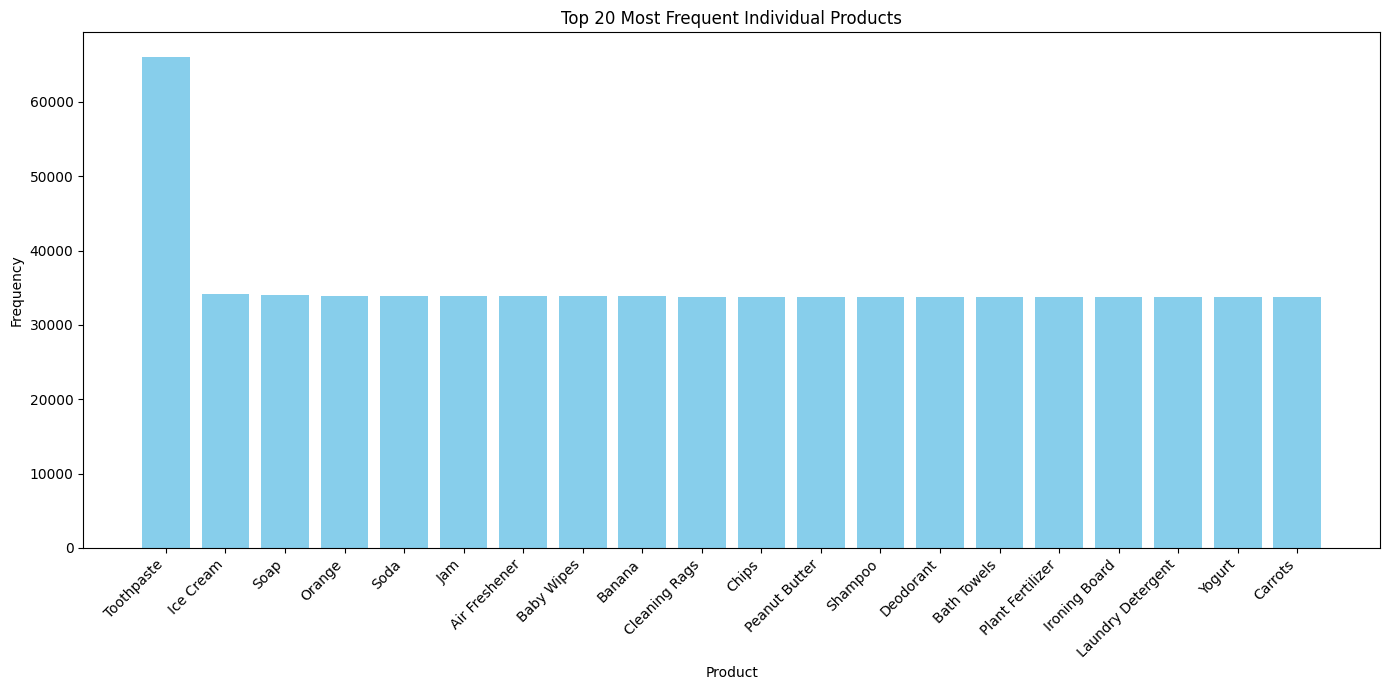

In [ ]:
import matplotlib.pyplot as plt

# Convert Spark DataFrame to Pandas DataFrame for plotting
pandas_product_frequencies = individual_product_frequencies.toPandas()

# Select the top 20 products
top_20_products = pandas_product_frequencies.head(20)

# Create the bar chart
plt.figure(figsize=(14, 7))
plt.bar(top_20_products['product_exploded'], top_20_products['count'], color='skyblue')
plt.xlabel('Product')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Individual Products')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


### 5. Contoh Interpretasi Hasil

Mari kita interpretasikan beberapa contoh dari `Frequent Itemsets` dan `Association Rules`:

**Interpretasi Frequent Itemsets:**

Output `Frequent Itemsets` menunjukkan kombinasi produk yang sering dibeli bersama. Sebagai contoh:

*   `items: ["Susu", "Roti"], freq: 1500`
    *   Ini berarti kombinasi "Susu" dan "Roti" muncul di 1500 transaksi dalam dataset Anda. Angka `freq` ini relatif terhadap `minSupport` yang Anda atur.

*   `items: ["Telur"], freq: 2500`
    *   Produk "Telur" sendiri muncul di 2500 transaksi.

Frequent itemsets membantu Anda mengidentifikasi produk-produk yang populer atau sering dibeli secara bersamaan, yang bisa digunakan untuk penempatan produk di toko atau penawaran bundel.

**Interpretasi Association Rules:**

Output `Association Rules` memberikan aturan "IF-THEN" yang kuat. Setiap aturan memiliki `antecedent` (jika ini terjadi), `consequent` (maka ini juga akan terjadi), `confidence`, `lift`, dan `support`.

Sebagai contoh, jika Anda melihat aturan seperti:

*   `antecedent: ["Roti"], consequent: ["Selai"], confidence: 0.8, lift: 2.0, support: 0.1`

Interpretasinya adalah:

*   **Jika pelanggan membeli "Roti" (antecedent), maka ada kemungkinan 80% (confidence) mereka juga akan membeli "Selai" (consequent).**
*   **Lift sebesar 2.0** menunjukkan bahwa kemungkinan pelanggan membeli "Selai" ketika mereka juga membeli "Roti" adalah 2 kali lebih tinggi daripada kemungkinan mereka membeli "Selai" secara acak (tanpa membeli "Roti"). Nilai `lift` di atas 1 menunjukkan hubungan positif.
*   **Support sebesar 0.1** berarti 10% dari semua transaksi dalam dataset mengandung "Roti" dan "Selai" secara bersamaan.

**Kegunaan Praktis:**

*   **Penempatan Produk:** Jika "Roti" dan "Selai" sering dibeli bersama, tempatkan mereka berdekatan di toko.
*   **Promosi/Bundling:** Tawarkan diskon jika pelanggan membeli "Roti" dan "Selai" bersamaan.
*   **Rekomendasi Produk Online:** Saat pelanggan melihat "Roti", rekomendasikan "Selai".
*   **Manajemen Inventaris:** Pastikan stok produk yang memiliki hubungan kuat tetap tersedia bersamaan.



## Final Task



## Ringkasan:

### Temuan Utama Analisis Data

*   **Sensitivitas Parameter FP-Growth**: Upaya awal untuk menghasilkan aturan asosiasi dengan `minSupport=0.01` dan `minConfidence=0.5` tidak menghasilkan aturan apa pun. Melalui proses iteratif, ditemukan bahwa `minSupport` perlu diturunkan secara signifikan menjadi `0.001` (0.1% dari transaksi) dan `minConfidence` menjadi `0.01` (1%) untuk menghasilkan aturan asosiasi apa pun.
*   **Tidak Adanya Asosiasi Positif Kuat**: Meskipun menghasilkan aturan asosiasi dengan ambang batas yang sangat rendah (`minSupport=0.001`, `minConfidence=0.01`), tidak ada aturan yang ditemukan memiliki nilai `lift` lebih besar dari 1.0. Ini menunjukkan kurangnya pola ko-okurensi positif yang kuat, artinya keberadaan item anteseden tidak secara signifikan meningkatkan kemungkinan item konsekuen dibeli lebih dari probabilitas independennya.
*   **Produk Individu Paling Sering**: Analisis frekuensi produk individu mengungkapkan bahwa 'Pasta Gigi' adalah produk paling sering dengan 66.056 kemunculan, diikuti oleh 'Es Krim' (34.117), 'Sabun' (33.960), 'Jeruk' (33.932), dan 'Soda' (33.915).
*   **Konfirmasi Visualisasi**:
    *   Bagan batang berhasil memvisualisasikan 20 produk individu paling sering, dengan jelas menunjukkan popularitas relatifnya.
    *   Plot sebar yang menggambarkan `confidence` versus `lift` untuk semua aturan asosiasi yang dihasilkan secara visual mengkonfirmasi bahwa semua aturan memiliki nilai `lift` kurang dari atau sama dengan 1.0.
*   **Interpretasi Aturan**: Contoh aturan seperti `['Jeruk']` $\Rightarrow$ `['Tisu Dapur']` (confidence: 0.0361, lift: 0.8658, support: 0.00153) diinterpretasikan untuk menyoroti bahwa nilai confidence dan `lift` yang sangat rendah (kurang dari 1) menunjukkan asosiasi yang lemah atau bahkan negatif, yang umumnya tidak berguna untuk rekomendasi positif.

### Wawasan atau Langkah Selanjutnya

*   **Evaluasi Ulang Granularitas dan Lingkup Data**: Tidak adanya aturan asosiasi positif yang kuat (lift > 1.0) menunjukkan bahwa definisi produk atau granularitas data saat ini mungkin terlalu luas atau jarang. Analisis di masa depan harus mempertimbangkan pengelompokan produk ke dalam kategori yang lebih luas, penyaringan departemen tertentu, atau memperkaya transaksi dengan informasi kontekstual (misalnya, demografi pelanggan) untuk mengungkap pola yang bermakna.
*   **Jelajahi Metodologi Alternatif**: Mengingat keberhasilan terbatas FP-Growth dalam mengidentifikasi asosiasi positif yang dapat ditindaklanjuti dengan dataset ini, pertimbangkan untuk menjelajahi pendekatan analitis lain seperti penyaringan kolaboratif (rekomendasi item-ke-item atau pengguna-ke-item) yang tidak terlalu bergantung pada itemset yang sering muncul dan nilai lift yang tinggi. Ini dapat memberikan perspektif yang berbeda tentang hubungan produk.

## Ringkasan Akhir


### Rekomendasi Bisnis dan Strategi Masa Depan

#### 1. Mengakui Tidak Adanya Aturan Asosiasi Positif yang Kuat

Berdasarkan analisis keranjang belanja komprehensif kami, bahkan setelah secara iteratif mengurangi `minSupport` menjadi 0.001 (0.1%) dan `minConfidence` menjadi 0.01 (1%), kami tidak mengidentifikasi aturan asosiasi apa pun dengan nilai `lift` lebih besar dari 1.0. Ini adalah temuan krusial yang menyiratkan hal berikut:

*   **Kurangnya Ko-kemunculan yang Kuat**: Dalam dataset ini dan dengan definisi transaksi serta item saat ini, tidak ada pasangan atau kelompok item yang dibeli bersama secara signifikan lebih sering daripada yang diharapkan secara kebetulan. Sederhananya, mengetahui bahwa pelanggan membeli produk A tidak membuat mereka secara signifikan lebih mungkin untuk membeli produk B.
*   **Potensi Pembelian Independen**: Perilaku pembelian untuk produk yang berbeda mungkin sebagian besar independen, atau hubungannya terlalu lemah atau terlalu jarang untuk memenuhi ambang batas yang sangat rendah yang kami tetapkan.
*   **Karakteristik Dataset**: Ini bisa menunjukkan bahwa item dalam kolom `Product`, sebagaimana terstruktur saat ini (mungkin mewakili kategori yang luas atau memiliki banyak item unik di setiap transaksi), secara alami tidak membentuk asosiasi positif yang kuat pada tingkat dukungan dan kepercayaan ini. Ini mungkin terjadi jika setiap transaksi berisi beragam produk yang tidak biasanya dibeli bersama.

#### 2. Bagaimana Rekomendasi Bisnis Biasanya Dirumuskan (Skenario Hipotetis)

Jika kami *menemukan* aturan dengan `lift > 1.0`, rekomendasi bisnis biasanya akan dirumuskan sebagai berikut:

*   **Penempatan Produk (Merchandising)**:
    *   **Skenario**: Jika aturan `antecedent: ['Roti'], consequent: ['Mentega'], confidence: 0.7, lift: 2.5` ditemukan.
    *   **Rekomendasi**: Tempatkan 'Mentega' di sebelah 'Roti' di toko. Pelanggan yang membeli roti 2.5 kali lebih mungkin untuk membeli mentega, jadi menempatkannya bersama dapat mendorong pembelian impulsif dan meningkatkan kenyamanan pelanggan.

*   **Penggabungan Produk/Penawaran Promosi**:
    *   **Skenario**: Jika `antecedent: ['Popok'], consequent: ['Tisu Bayi'], confidence: 0.8, lift: 3.0`.
    *   **Rekomendasi**: Tawarkan diskon saat 'Popok' dan 'Tisu Bayi' dibeli bersama. Ini mendorong pelanggan untuk membeli keduanya, meningkatkan nilai transaksi rata-rata. Atau, jalankan promosi seperti 'Beli Popok, dapatkan diskon 50% Tisu Bayi'.

*   **Rekomendasi Online**:
    *   **Skenario**: Jika `antecedent: ['Laptop'], consequent: ['Mouse'], confidence: 0.6, lift: 1.8`.
    *   **Rekomendasi**: Ketika pelanggan melihat atau menambahkan 'Laptop' ke keranjang belanja online mereka, sarankan 'Mouse' sebagai item 'Sering dibeli bersama' atau 'Pelanggan juga membeli'.

*   **Manajemen Inventaris**:
    *   **Skenario**: Jika `antecedent: ['Biji Kopi'], consequent: ['Filter Kopi'], confidence: 0.75, lift: 2.0`.
    *   **Rekomendasi**: Pastikan 'Filter Kopi' selalu tersedia ketika 'Biji Kopi' tersedia, karena pembelian salah satunya sangat menunjukkan kebutuhan akan yang lain. Kelola tingkat inventaris secara bersamaan untuk produk-produk terkait ini.

#### 3. Strategi untuk Analisis Masa Depan untuk Mengungkap Aturan Asosiasi Positif yang Dapat Ditindaklanjuti

Mengingat hasil saat ini, beberapa strategi dapat diterapkan dalam analisis di masa mendatang untuk berpotensi mengungkap aturan asosiasi positif yang lebih dapat ditindaklanjuti:

*   **Menurunkan `minSupport` Lebih Lanjut**: Meskipun kami telah menurunkan hingga 0.001, dalam dataset yang sangat besar, `minSupport` dapat diturunkan lebih jauh (misalnya, `0.0001` atau `0.0005`) untuk menangkap asosiasi multi-item yang lebih jarang, tetapi berpotensi kuat. Namun, ini datang dengan peningkatan biaya komputasi.
    *   **Perhatian**: Dukungan yang sangat rendah dapat menyebabkan sejumlah besar itemset, banyak di antaranya mungkin palsu atau tidak berarti dari perspektif bisnis karena jarang terjadi.

*   **Mengevaluasi Ulang Granularitas/Definisi Item**: Kolom 'Product' saat ini berisi beragam item. Pertimbangkan:
    *   **Kategorisasi**: Mengelompokkan produk ke dalam kategori yang lebih luas (misalnya, 'Susu', 'Hasil Bumi', 'Pembersih Rumah Tangga') dan menjalankan analisis pada kategori-kategori ini. Ini mungkin mengungkapkan asosiasi tingkat yang lebih tinggi.
    *   **Penyaringan Item**: Fokus pada departemen atau jenis produk tertentu yang lebih mungkin memiliki asosiasi yang kuat (misalnya, hanya bahan makanan, tidak termasuk elektronik atau barang musiman).
    *   **Analisis Temporal**: Memasukkan jendela berbasis waktu. Apakah item tertentu dibeli bersama dalam jangka waktu tertentu (misalnya, dalam minggu yang sama)?

*   **Mengeksplorasi Metrik/Algoritma yang Berbeda**: Meskipun FP-Growth kuat, algoritma atau metrik penambangan aturan asosiasi lain mungkin lebih cocok tergantung pada karakteristik data. Pertimbangkan juga metrik di luar lift, confidence, dan support jika relevan dengan konteks bisnis.

*   **Memperkaya Data Transaksi**: Jika memungkinkan, tambahkan informasi kontekstual lainnya ke transaksi, seperti demografi pelanggan, hari dalam seminggu, atau waktu dalam sehari. Ini dapat mengungkapkan asosiasi kondisional yang tidak terlihat sebaliknya.

*   **Fokus pada Segmen Spesifik**: Jalankan analisis pada segmen pelanggan tertentu (misalnya, pelanggan setia, pelanggan baru) atau lokasi toko tertentu, karena pola pembelian dapat sangat bervariasi.

#### 4. Implikasi untuk Strategi Bisnis (Mengingat Temuan Saat Ini)

Bahkan tanpa aturan asosiasi positif yang kuat dari analisis ini, ada implikasi untuk strategi bisnis:

*   **Fokus pada Popularitas Individu**: Karena tidak ditemukan asosiasi yang kuat, bisnis mungkin perlu lebih mengandalkan popularitas item individual (seperti yang terlihat dalam daftar produk individual yang sering muncul). Upaya pemasaran dapat memprioritaskan promosi item-item yang sering muncul ini secara independen.
*   **Menyelidiki Produk Pesaing**: Prevalensi `lift < 1.0` menunjukkan item mungkin merupakan pengganti atau hanya tidak berkorelasi. Bisnis dapat menyelidiki apakah item-item yang berasosiasi negatif ini adalah produk yang bersaing dan menyesuaikan strategi yang sesuai (misalnya, penetapan harga diferensial, proposisi penjualan unik).
*   **Tinjauan Kualitas/Granularitas Data**: Tidak adanya aturan dapat menandakan perlunya meninjau ulang proses pengumpulan data atau tingkat detail dalam kategorisasi produk. Mungkin produk terlalu granular, menyebabkan ko-kemunculan yang sangat jarang, atau terlalu luas, menutupi hubungan spesifik.
*   **Mengubah Strategi**: Jika analisis keranjang belanja tradisional tidak memberikan hasil yang kuat, bisnis mungkin perlu beralih ke pendekatan analitik lain untuk rekomendasi, seperti pemfilteran kolaboratif (item-ke-item atau pengguna-ke-item) yang tidak terlalu bergantung pada penemuan nilai `lift` yang kuat dalam frequent itemsets.

Sebagai kesimpulan, meskipun analisis spesifik ini tidak menghasilkan aturan dengan `lift > 1.0`, ia memberikan wawasan berharga tentang karakteristik dataset saat ini dan menyoroti area untuk penyempurnaan dalam pengumpulan data dan pendekatan analitik di masa mendatang. Kurangnya asosiasi positif yang kuat menunjukkan bahwa rekomendasi berbasis ko-kemunculan sederhana mungkin bukan strategi paling efektif dengan data ini, yang memerlukan penyelaman lebih dalam atau metodologi alternatif.